# Ноутбук 05. Attention-діагностика помилок класифікатора $f_B$

Ноутбук реалізує **Перевірку 3** тези (розділ 2.3): якісний аналіз помилкових передбачень класифікатора $f_B$ за допомогою attention-карт BERT (теза 1.6). Аналізуємо три навчені моделі з ноутбука 04 ($\text{GaussianNB}$, $\text{LogReg}$, $\text{LinearSVC}$) на тестовому сплеті, з фокусом на:

1. **FP/FN кожної моделі** — для кожного шаблону, який класифікатор передбачив неправильно, дивимось, на які токени дивиться [CLS]. Це показує, чи модель ігнорує сигнальні слова (`exception`, `error`, `interrupted`) або переоцінює нейтральні (теза 1.6, лінії 903–907).
2. **Множина розбіжностей** $\text{DIS}$ — шаблони, на яких три моделі дають різні передбачення. Оскільки attention BERT не залежить від наступного класифікатора, [CLS]-розподіл уваги тут — спільна семантична основа, на якій лінійні моделі (LogReg/LinearSVC) розпізнають структуру, що губиться GaussianNB. Цей блок прив’язаний до тверджень про лінійну роздільність у анізотропному просторі (теза 1.7, 1.9).

Артефакти: PNG-фігури в `data/processed/attention/{GaussianNB,LogReg,LinearSVC}/` та `data/processed/attention/disagreement/`. Метрик не експортуємо — це чисто діагностичний ноутбук.

In [1]:
from __future__ import annotations

import os

# CPU single-thread (same idiom as nb04) — must precede numpy/sklearn import.
for _var in (
    "OMP_NUM_THREADS",
    "MKL_NUM_THREADS",
    "OPENBLAS_NUM_THREADS",
    "BLIS_NUM_THREADS",
    "VECLIB_MAXIMUM_THREADS",
    "NUMEXPR_NUM_THREADS",
):
    os.environ[_var] = "1"

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
from transformers import BertModel

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATA_PROCESSED = ROOT / 'data' / 'processed'
EMBEDDINGS_DIR = DATA_PROCESSED / 'embeddings'
CLUSTERS_DIR = DATA_PROCESSED / 'clusters'
RESULTS_DIR = DATA_PROCESSED / 'classification'
ATTENTION_DIR = DATA_PROCESSED / 'attention'
ATTENTION_DIR.mkdir(parents=True, exist_ok=True)

from src.attention.extractor import extract_cls_attention
from src.bert.vectorizer import TemplateVectorizer
from src.classification.trainer import evaluate, fit_with_timing, make_classifiers
from src.io.persistence import load_json, load_numpy

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

print(f'numpy = {np.__version__}')
print(f'torch = {torch.__version__}')

/Users/roman/Personal/dyploma/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


numpy = 2.4.4
torch = 2.11.0


## 1. Відтворення трьох класифікаторів з ноутбука 04

Завантажуємо ті ж артефакти, що в ноутбуці 04, виконуємо ту саму нормалізацію та стратифіковане 80/20 розбиття із `random_state=42`, потім тренуємо ті самі три класифікатори через `make_classifiers(random_state=42)` та `fit_with_timing(..., sample_weight=w_train)`. Baseline пропускаємо — для attention-аналізу він не потрібен.

Останній рядок — асерт відтворюваності: значення MCC мають збігатись із `metrics_fb.csv` з точністю $10^{-9}$. Якщо assert падає — це означає, що nb05 аналізує не ті моделі, що нb04 експортував.

In [2]:
embeddings = load_numpy(EMBEDDINGS_DIR / 'zookeeper_full_embeddings.npy')
id_mapping: list[dict] = load_json(EMBEDDINGS_DIR / 'zookeeper_full_id_mapping.json')
template_to_label = load_json(CLUSTERS_DIR / 'template_to_binary_label.json')
template_to_rule = load_json(CLUSTERS_DIR / 'template_to_rule_label.json')

final_by_tid: dict[int, int] = {r['template_id']: r['final_label'] for r in template_to_label}
support_by_tid: dict[int, int] = {r['template_id']: r['support'] for r in template_to_label}
rule_by_tid: dict[int, int] = {r['template_id']: r['rule_label'] for r in template_to_rule}
template_text_by_tid: dict[int, str] = {r['template_id']: r['template'] for r in template_to_label}

# Aligned to id_mapping row order — same as nb04.
X = embeddings.astype(np.float32)
y = np.array([final_by_tid[m['template_id']] for m in id_mapping], dtype=int)
w = np.array([support_by_tid[m['template_id']] for m in id_mapping], dtype=float)
y_rule = np.array([rule_by_tid[m['template_id']] for m in id_mapping], dtype=int)
template_ids = np.array([m['template_id'] for m in id_mapping], dtype=int)

X_norm = normalize(X, norm='l2', axis=1).astype(np.float32)

(
    X_train, X_test,
    y_train, y_test,
    w_train, w_test,
    y_rule_train, y_rule_test,
    tid_train, tid_test,
) = train_test_split(
    X_norm, y, w, y_rule, template_ids,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)
print(f'test split: {X_test.shape[0]} templates, classes = {dict(zip(*np.unique(y_test, return_counts=True)))}')

classifiers = make_classifiers(random_state=RANDOM_STATE)
for name, clf in classifiers.items():
    fit_with_timing(clf, X_train, y_train, sample_weight=w_train)

# Reproducibility assert against nb04 CSV.
metrics_csv = pd.read_csv(RESULTS_DIR / 'metrics_fb.csv', index_col='model')
for name, clf in classifiers.items():
    here = evaluate(clf, X_test, y_test, y_rule_test)
    csv_mcc = float(metrics_csv.loc[name, 'MCC'])
    assert abs(here['MCC'] - csv_mcc) < 1e-9, (
        f'{name}: nb05 MCC={here["MCC"]:.12f} disagrees with metrics_fb.csv MCC={csv_mcc:.12f}'
    )
    print(f'{name:<10} MCC={here["MCC"]:+.6f} (matches CSV)')
print('reproducibility assert passed: nb05 retrains the same 3 models as nb04.')

test split: 16 templates, classes = {np.int64(0): np.int64(12), np.int64(1): np.int64(4)}
GaussianNB MCC=+0.363696 (matches CSV)
LogReg     MCC=+0.462250 (matches CSV)
LinearSVC  MCC=+0.666667 (matches CSV)
reproducibility assert passed: nb05 retrains the same 3 models as nb04.


## 2. Завантаження BERT з extended tokenizer (eager attention)

Тут є нюанс. `TemplateVectorizer` завантажує `bert-base-uncased` зі стандартним SDPA-бекендом, який у `transformers 5.x` **не повертає** ваги уваги (`output_attentions=True` ігнорується). Тому:

1. Інстанціюємо `TemplateVectorizer` лише для **токенайзера** — він додає 7 плейсхолдерів (`<IP>`, `<NUM>`, `<PATH>`, `<HEX>`, `<EXC>`, `<SESSION>`, `<UUID>`) і виконує mean-init нових ембедингів, ідентично ноутбуку 02.
2. Окремо завантажуємо `BertModel` із `attn_implementation='eager'`, ресайзимо словник до розміру extended-токенайзера, і **копіюємо матрицю ембедингів** з `vectorizer.model` — це гарантує, що плейсхолдер-токени мають **точно ті самі** mean-ініціалізовані вектори, з якими nb02 векторизував шаблони. Без копії новий eager-модель отримав би випадкові ембединги для плейсхолдерів і attention перестав би бути порівнянним з nb02.

Без fine-tuning — pretrained BERT, як того вимагає теза.

In [3]:
vectorizer = TemplateVectorizer(device='cpu')
bert_tokenizer = vectorizer.tokenizer

bert_model = BertModel.from_pretrained('bert-base-uncased', attn_implementation='eager')
bert_model.resize_token_embeddings(len(bert_tokenizer))
with torch.no_grad():
    bert_model.embeddings.word_embeddings.weight.copy_(
        vectorizer.model.embeddings.word_embeddings.weight
    )
bert_model.eval()

# Sanity: placeholder tokens map to single IDs and have non-default embeddings.
for placeholder in ['<IP>', '<NUM>', '<HEX>', '<EXC>']:
    pid = bert_tokenizer.convert_tokens_to_ids(placeholder)
    assert pid != bert_tokenizer.unk_token_id, f'{placeholder} mapped to UNK'
print(f'tokenizer vocab = {len(bert_tokenizer)} (base 30522 + 7 placeholders)')
print(f'bert_model attn_implementation = {bert_model.config._attn_implementation!r}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 23291.29it/s]


[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[transformers] The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 17416.82it/s]


[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer vocab = 30529 (base 30522 + 7 placeholders)
bert_model attn_implementation = 'eager'


## 3. Функція витягування [CLS]-уваги

Реалізована у `src/attention/extractor.py`. Алгоритм (теза 1.6):

1. Токенізація шаблону зі спецтокенами `[CLS]`, `[SEP]` → `input_ids` форми $(1, S)$.
2. Forward з `output_attentions=True` → кортеж $L=12$ тензорів, кожен $(1, H, S, S)$, $H=12$.
3. Беремо останній шар $A^{(L)}$, усереднюємо по головах: $\bar{A}^{(L)} = \frac{1}{H} \sum_{h=1}^{H} A^{(L,h)} \in \mathbb{R}^{S \times S}$.
4. Витягуємо рядок $[\text{CLS}]$: $\bar{A}^{(L)}_{0, :} \in \mathbb{R}^{S}$ — увага токена $[\text{CLS}]$ до кожного токена послідовності.

Sanity-перевірка нижче — на шаблоні 44 `"Unexpected Exception:"` (ERROR-level, метка 1). Очікуємо ненульову увагу на токенах `exception` та `unexpected`.

In [4]:
tokens_sanity, att_sanity = extract_cls_attention(
    bert_model, bert_tokenizer, template_text_by_tid[44]
)
assert len(tokens_sanity) == att_sanity.size
assert abs(att_sanity.sum() - 1.0) < 1e-3, f'row sum ≈ 1 expected, got {att_sanity.sum()}'
print(f'template 44: "{template_text_by_tid[44]}"')
print(f'tokens ({len(tokens_sanity)}): {tokens_sanity}')
print('[CLS] attention per token:')
for tok, w_att in zip(tokens_sanity, att_sanity):
    print(f'  {tok:<14} {w_att:.4f}')

template 44: "Unexpected Exception:"
tokens (5): ['[CLS]', 'unexpected', 'exception', ':', '[SEP]']
[CLS] attention per token:
  [CLS]          0.2064
  unexpected     0.1383
  exception      0.1817
  :              0.2029
  [SEP]          0.2707


## 4. Помилки трьох моделей на тестовому сплеті

Для кожної моделі обчислюємо $\text{FP}_M = \{t : \hat{y}_M(t) = 1, y(t) = 0\}$ та $\text{FN}_M = \{t : \hat{y}_M(t) = 0, y(t) = 1\}$ на тестовому сплеті. Тест містить лише ~16 шаблонів (з них 12 негативних / 4 позитивних), тому деякі $\text{FP}_M$ або $\text{FN}_M$ можуть бути порожніми — це очікувано і **не** є дефектом, а наслідок малої вибірки (теза 2.4).

In [5]:
predictions_by_model: dict[str, np.ndarray] = {
    name: clf.predict(X_test) for name, clf in classifiers.items()
}

# errors_by_model[name] = {'FP': [tid, ...], 'FN': [tid, ...]} in test-row order.
errors_by_model: dict[str, dict[str, list[int]]] = {}
for name, y_pred in predictions_by_model.items():
    fp_mask = (y_pred == 1) & (y_test == 0)
    fn_mask = (y_pred == 0) & (y_test == 1)
    errors_by_model[name] = {
        'FP': tid_test[fp_mask].tolist(),
        'FN': tid_test[fn_mask].tolist(),
    }
    print(f'\n{name}: |FP|={fp_mask.sum()}, |FN|={fn_mask.sum()}')
    rows = []
    for kind, tids in errors_by_model[name].items():
        for tid in tids:
            rows.append({
                'kind': kind,
                'template_id': int(tid),
                'support': support_by_tid[int(tid)],
                'template': template_text_by_tid[int(tid)],
            })
    if rows:
        err_df = pd.DataFrame(rows).set_index(['kind', 'template_id'])
        with pd.option_context('display.max_colwidth', 100):
            print(err_df)
    else:
        print('  (no errors on test split)')


GaussianNB: |FP|=4, |FN|=1
                  support  \
kind template_id            
FP   65                 6   
     2                 36   
     55                13   
     4                 36   
FN   62                15   

                                                                                               template  
kind template_id                                                                                         
FP   65           Sending snapshot last zxid of peer is <HEX> zxid of leader is <*> zxid of db as <HEX>  
     2                                                                   Defaulting to majority quorums  
     55                                                                    SyncRequestProcessor exited!  
     4                                                             autopurge.purgeInterval set to <NUM>  
FN   62                                                      Commiting zxid <HEX> from /<IP> not first!  

LogReg: |FP|=1, |FN|=2
  

## 5. Per-model attention heatmaps (FP + FN)

Для кожної моделі та кожного помилкового шаблону рендеримо горизонтальний bar-chart ваг $[\text{CLS}] \to \text{token}$ останнього шару BERT (усереднених по головах). Заголовок включає назву моделі, `template_id`, передбачену та справжню мітку, support, тип помилки (FP/FN). Файли зберігаються в `data/processed/attention/<model>/fp_fn_<template_id>.png`.


[GaussianNB] rendering 5 heatmap(s):


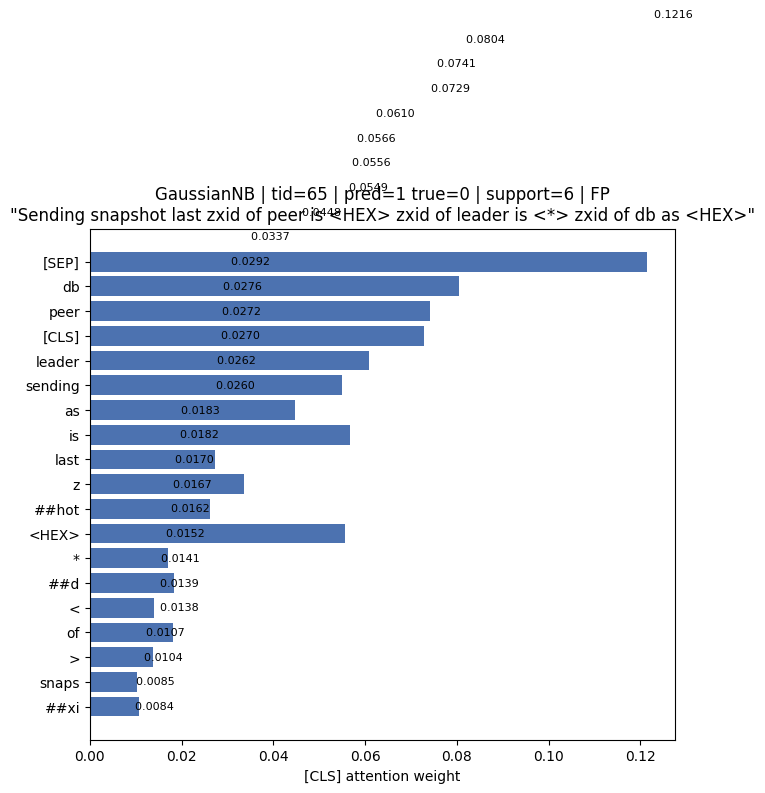

saved: /Users/roman/Personal/dyploma/data/processed/attention/GaussianNB/fp_fn_65.png


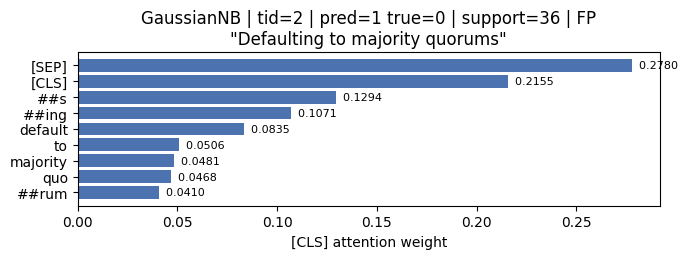

saved: /Users/roman/Personal/dyploma/data/processed/attention/GaussianNB/fp_fn_2.png


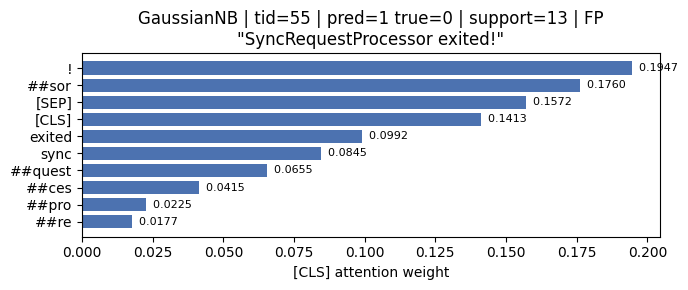

saved: /Users/roman/Personal/dyploma/data/processed/attention/GaussianNB/fp_fn_55.png


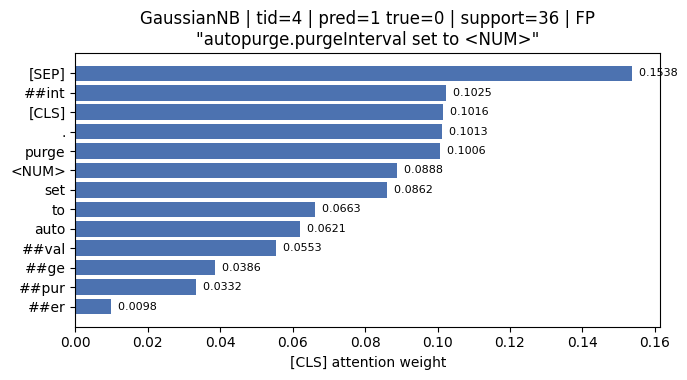

saved: /Users/roman/Personal/dyploma/data/processed/attention/GaussianNB/fp_fn_4.png


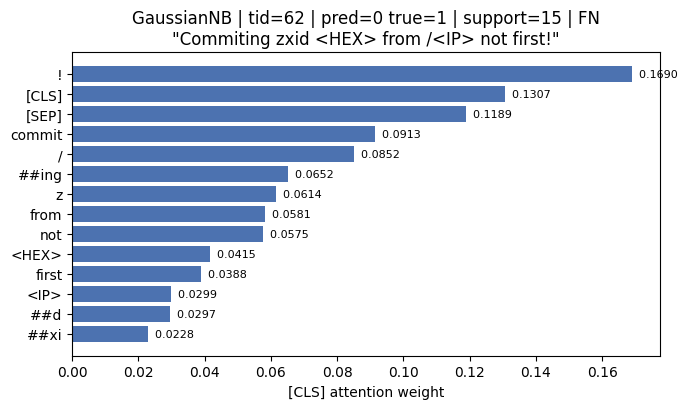

saved: /Users/roman/Personal/dyploma/data/processed/attention/GaussianNB/fp_fn_62.png

[LogReg] rendering 3 heatmap(s):


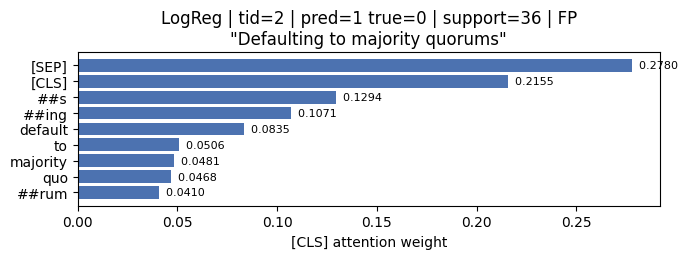

saved: /Users/roman/Personal/dyploma/data/processed/attention/LogReg/fp_fn_2.png


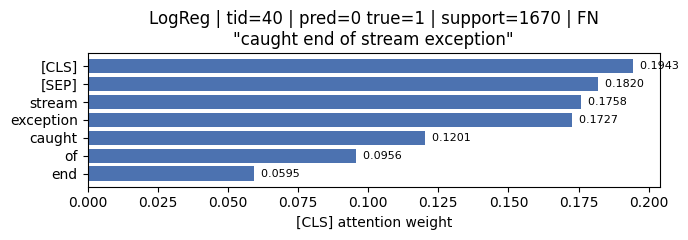

saved: /Users/roman/Personal/dyploma/data/processed/attention/LogReg/fp_fn_40.png


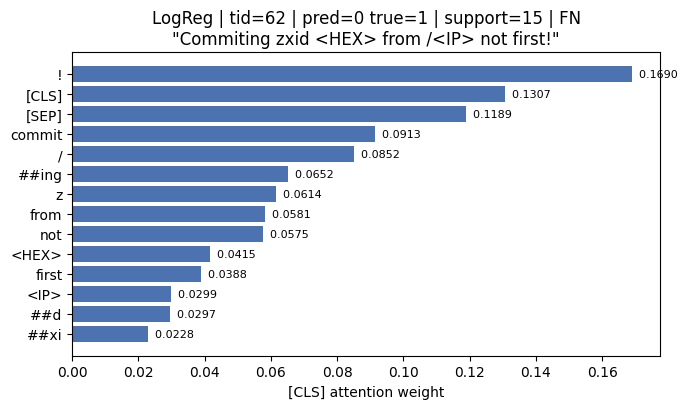

saved: /Users/roman/Personal/dyploma/data/processed/attention/LogReg/fp_fn_62.png

[LinearSVC] rendering 2 heatmap(s):


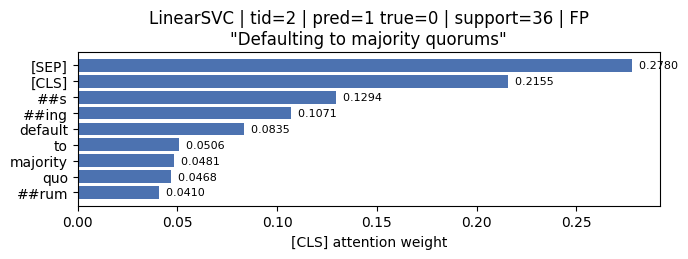

saved: /Users/roman/Personal/dyploma/data/processed/attention/LinearSVC/fp_fn_2.png


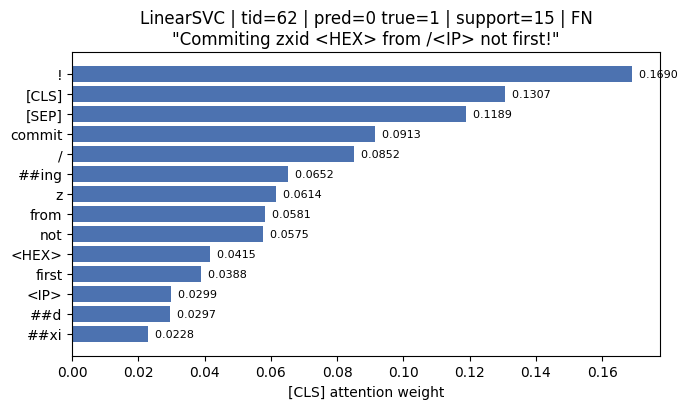

saved: /Users/roman/Personal/dyploma/data/processed/attention/LinearSVC/fp_fn_62.png


In [6]:
def render_cls_attention_bar(
    tokens: list[str],
    attention: np.ndarray,
    title: str,
    save_path: Path,
) -> None:
    """Horizontal bar chart of [CLS]->token attention; saves PNG at `save_path`.

    Token labels on y-axis (readable for long subword sequences); attention
    magnitude on x-axis. Highest-attention token at the top. The 4-decimal
    annotation next to each bar speeds up qualitative comparison of figures.
    """
    fig_h = max(2.5, 0.3 * len(tokens))
    plt.figure(figsize=(7, fig_h))
    order = np.argsort(attention)
    plt.barh([tokens[i] for i in order], attention[order], color='#4C72B0')
    plt.xlabel('[CLS] attention weight')
    plt.title(title)
    for i, idx in enumerate(order):
        plt.text(attention[idx], i, f'  {attention[idx]:.4f}', va='center', fontsize=8)
    plt.tight_layout()
    save_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'saved: {save_path}')


figures_written: list[Path] = []
for name, err in errors_by_model.items():
    union_tids = list(dict.fromkeys(err['FP'] + err['FN']))  # dedup, preserve order
    if not union_tids:
        print(f'\n[{name}] no FP/FN on test split — nothing to render')
        continue
    print(f'\n[{name}] rendering {len(union_tids)} heatmap(s):')
    for tid in union_tids:
        kind = 'FP' if tid in err['FP'] else 'FN'
        text = template_text_by_tid[tid]
        support = support_by_tid[tid]
        true_label = final_by_tid[tid]
        pred_label = 1 - true_label  # by definition of FP/FN
        tokens_i, att_i = extract_cls_attention(bert_model, bert_tokenizer, text)
        title = (
            f'{name} | tid={tid} | pred={pred_label} true={true_label} | '
            f'support={support} | {kind}\n"{text}"'
        )
        save_path = ATTENTION_DIR / name / f'fp_fn_{tid}.png'
        render_cls_attention_bar(tokens_i, att_i, title, save_path)
        figures_written.append(save_path)

## 6. Множина розбіжностей DIS

$\text{DIS} = \{ t \in \text{test} : \exists\, M_i, M_j \text{ із трьох моделей, що } \hat{y}_{M_i}(t) \neq \hat{y}_{M_j}(t) \}$.

Це ключовий блок аналізу: якщо лінійні моделі (LogReg, LinearSVC) роздають клас $1$ на шаблоні, а GaussianNB — клас $0$, це сигнал, що шаблон **лінійно роздільний** у вихідному 768-вимірному просторі BERT, але NB-припущення про незалежність ознак заважає GaussianNB його розпізнати (теза 1.7 анізотропія + 1.9 лінійна роздільність).

BERT-увага не залежить від downstream-класифікатора — рендеримо її **один раз** на шаблон, а в заголовку фігури позначаємо, які моделі дали правильну ($\checkmark$) чи неправильну ($\times$) відповідь. Якщо $\text{DIS} = \emptyset$, переходимо до fallback: об’єднання $\bigcup_M (\text{FP}_M \cup \text{FN}_M)$.

DIS size: 4 of 16 test templates
discussion set: DIS = [65, 40, 55, 4]

             support  y_expert  y_rule  pred_GaussianNB  pred_LogReg  pred_LinearSVC                                                                               template
template_id                                                                                                                                                                
65                 6         0       0                1            0               0  Sending snapshot last zxid of peer is <HEX> zxid of leader is <*> zxid of db as <HEX>
40              1670         1       1                1            0               1                                                         caught end of stream exception
55                13         0       0                1            0               0                                                           SyncRequestProcessor exited!
4                 36         0       0                1            0

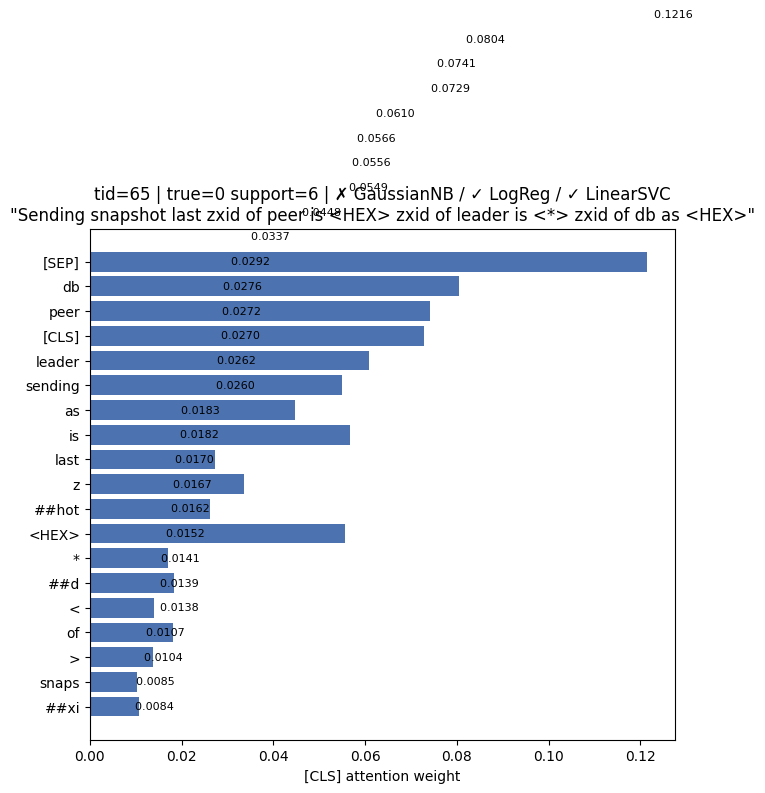

saved: /Users/roman/Personal/dyploma/data/processed/attention/disagreement/dis_65.png


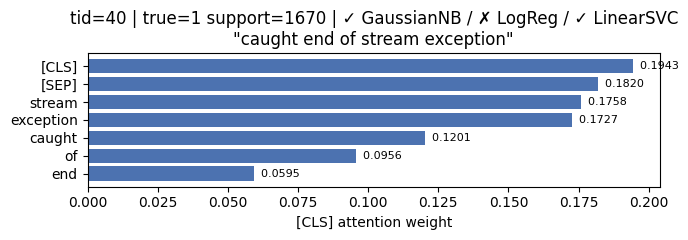

saved: /Users/roman/Personal/dyploma/data/processed/attention/disagreement/dis_40.png


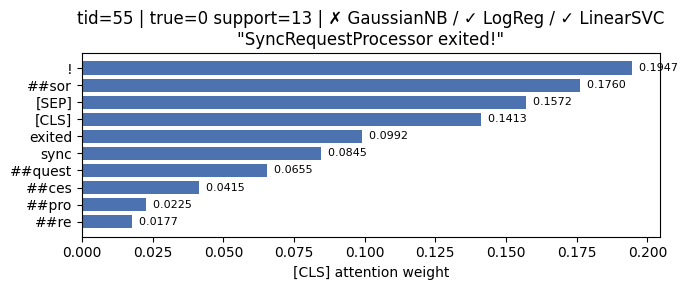

saved: /Users/roman/Personal/dyploma/data/processed/attention/disagreement/dis_55.png


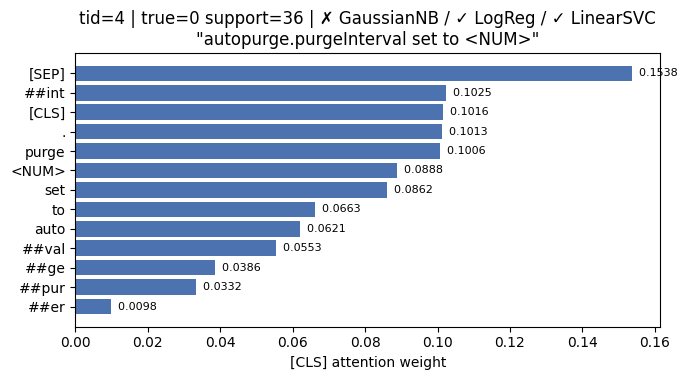

saved: /Users/roman/Personal/dyploma/data/processed/attention/disagreement/dis_4.png


In [7]:
model_names = list(classifiers.keys())  # GaussianNB, LogReg, LinearSVC
Y_pred = np.stack([predictions_by_model[m] for m in model_names], axis=0)  # (3, n_test)
dis_mask = ~(np.all(Y_pred == Y_pred[0:1], axis=0))                          # (n_test,)
dis_tids = tid_test[dis_mask].tolist()
print(f'DIS size: {len(dis_tids)} of {dis_mask.size} test templates')

if dis_tids:
    discussion_tids = dis_tids
    sub_dir = ATTENTION_DIR / 'disagreement'
    prefix = 'dis'
    print(f'discussion set: DIS = {discussion_tids}')
else:
    union: list[int] = []
    for err in errors_by_model.values():
        for tid in err['FP'] + err['FN']:
            if tid not in union:
                union.append(tid)
    discussion_tids = union
    sub_dir = ATTENTION_DIR / 'disagreement'
    prefix = 'fallback_union'
    print('DIS is empty — three models agree on every test template.')
    print(f'fallback discussion set (union of FP+FN across models): {discussion_tids}')

if discussion_tids:
    summary_rows = []
    for tid in discussion_tids:
        # Row index of this tid in the test split.
        test_pos = int(np.where(tid_test == tid)[0][0])
        row = {
            'template_id': tid,
            'support': support_by_tid[tid],
            'y_expert': final_by_tid[tid],
            'y_rule': rule_by_tid[tid],
        }
        for m in model_names:
            row[f'pred_{m}'] = int(predictions_by_model[m][test_pos])
        row['template'] = template_text_by_tid[tid]
        summary_rows.append(row)
    dis_df = pd.DataFrame(summary_rows).set_index('template_id')
    with pd.option_context('display.max_colwidth', 100, 'display.width', 200):
        print('\n', dis_df, sep='')

    for tid in discussion_tids:
        test_pos = int(np.where(tid_test == tid)[0][0])
        text = template_text_by_tid[tid]
        true_label = final_by_tid[tid]
        verdicts = []
        for m in model_names:
            ok = predictions_by_model[m][test_pos] == true_label
            verdicts.append(f'{"✓" if ok else "✗"} {m}')
        title = (
            f'tid={tid} | true={true_label} support={support_by_tid[tid]} | '
            + ' / '.join(verdicts) + f'\n"{text}"'
        )
        tokens_i, att_i = extract_cls_attention(bert_model, bert_tokenizer, text)
        save_path = sub_dir / f'{prefix}_{tid}.png'
        render_cls_attention_bar(tokens_i, att_i, title, save_path)
        figures_written.append(save_path)
else:
    print('Neither DIS nor union has elements — nothing to render in this block.')

### Аналітичний коментар до блоку розбіжностей

Згідно з тезою 1.7, pretrained BERT без fine-tuning розміщує всі контекстуальні вектори у вузькому конусі $\mathbb{R}^{768}$, де навіть семантично далекі речення мають високу косинусну подібність (0.6–0.97). Це означає, що **не кожна модель** здатна побачити роздільність у такому анізотропному просторі:

* $\textbf{GaussianNB}$ припускає **діагональну** коваріаційну матрицю кожного класу, тобто незалежність ознак. У анізотропному просторі реальна геометрія класів — це повернуті, витягнуті еліпсоїди, і діагональне наближення системно недооцінює клас $1$ для шаблонів, де сигнал розподілений по корельованих координатах (типово — exception-templates, де всі ознаки одночасно зсунуті).
* $\textbf{LogReg}$ та $\textbf{LinearSVC}$ навчаються **гіперплощини у повному 768-вимірному просторі**, тому вловлюють відносну геометрію класів незалежно від конуса (теза 1.9 — лінійна роздільність перевіряється безпосередньо метриками лінійних класифікаторів у $\mathbb{R}^{768}$).

Якщо $\text{DIS}$ непорожня, шаблони в ній мають bar-chart, де високі ваги [CLS] зосереджені на токенах, які лінійні моделі використовують як ознаки сигналу (`exception`, `error`, `interrupted`, `broken`), але GaussianNB не може скомбінувати в одну ймовірність через припущення незалежності. Якщо $\text{DIS}$ порожня — три моделі узгоджуються на всьому тесті, і єдині помилки походять від спільних труднощів (типово — короткі шаблони з малим support, де BERT-увага розмазана).

## 7. Висновки

Ноутбук реалізує **Перевірку 3** тези (розділ 2.3): якісний аналіз помилкових передбачень класифікатора $f_B$ через [CLS]-увагу останнього шару BERT. Для кожної з трьох моделей побудовано attention-карти на FP/FN тестового сплету та проаналізовано шаблони, на яких моделі дають різні передбачення. Аналітичний коментар прив’язано до тверджень тези про анізотропію BERT (1.7) і лінійну роздільність у вихідному 768-вимірному просторі (1.9).

Артефакти ноутбука — PNG-фігури в `data/processed/attention/`. Для подальших ітерацій з експертними коригуваннями (теза 2.3 Перевірка 2) ці фігури є відправною точкою — модель expert-loop переглядає шаблони з помилковими передбаченнями і змінює `final_label` у разі потреби.

In [8]:
n_pngs_on_disk = len(list(ATTENTION_DIR.rglob('*.png')))
print(f'figures rendered this run: {len(figures_written)}')
print(f'PNG files now on disk under {ATTENTION_DIR}: {n_pngs_on_disk}')
print(f'DIS template_ids: {dis_tids if dis_tids else "(empty)"}')
assert n_pngs_on_disk >= len(figures_written), 'lost figures on disk?'

figures rendered this run: 14
PNG files now on disk under /Users/roman/Personal/dyploma/data/processed/attention: 14
DIS template_ids: [65, 40, 55, 4]
